<a href="https://colab.research.google.com/github/JLettsSJU931/Machine-Learning-FA26/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
#Load the dataset into a Pandas DataFrame.
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.base import BaseEstimator, TransformerMixin

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [90]:
#Use structural inspection methods (head(), info(), describe()) to analyze features such as tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [91]:
#Drop any non-informative identifiers (such as customerID).
df = df.drop(columns=['customerID'])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [92]:
#Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges)...
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [93]:
#...and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.
imp = SimpleImputer(missing_values=np.nan, strategy='median')
imp.fit(df[['TotalCharges']])
df[['TotalCharges']]= imp.fit_transform(df[['TotalCharges']])
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [102]:
#Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler)
#to numerical columns and encoding (OneHotEncoder) to categorical columns.
num_trans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_trans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
half_pipeline = ColumnTransformer(transformers=[
    ("num", num_trans, make_column_selector(dtype_include=np.number)),
    ("cat", cat_trans, make_column_selector(dtype_include=object)),
])
df_test = half_pipeline.fit_transform(df)
print(df_test)

[[-0.43991649 -1.27744458 -1.16032292 ...  0.          1.
   0.        ]
 [-0.43991649  0.06632742 -0.25962894 ...  1.          1.
   0.        ]
 [-0.43991649 -1.23672422 -0.36266036 ...  1.          0.
   1.        ]
 ...
 [-0.43991649 -0.87024095 -1.1686319  ...  0.          1.
   0.        ]
 [ 2.27315869 -1.15528349  0.32033821 ...  1.          0.
   1.        ]
 [-0.43991649  1.36937906  1.35896134 ...  0.          1.
   0.        ]]


In [119]:
#Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.
from sklearn.linear_model import SGDClassifier

full_pipeline = Pipeline(steps=[
    ('preprocessor', half_pipeline),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42))
])

Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.


 Confusion matrix:
[[944  91]
 [194 180]]

 Classification report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409

ROC_AUC: 0.8503410059676044

 Confusion matrix:
[[1253  299]
 [ 193  368]]

 Classification report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1552
           1       0.55      0.66      0.60       561

    accuracy                           0.77      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.78      0.77      0.77      2113

ROC_AUC: 0.8331828748369074

 Confusion matrix:
[[1856  214]
 [ 351  397]]

 Classification report:
              precision    recall  f1-score   support

           0       0.84

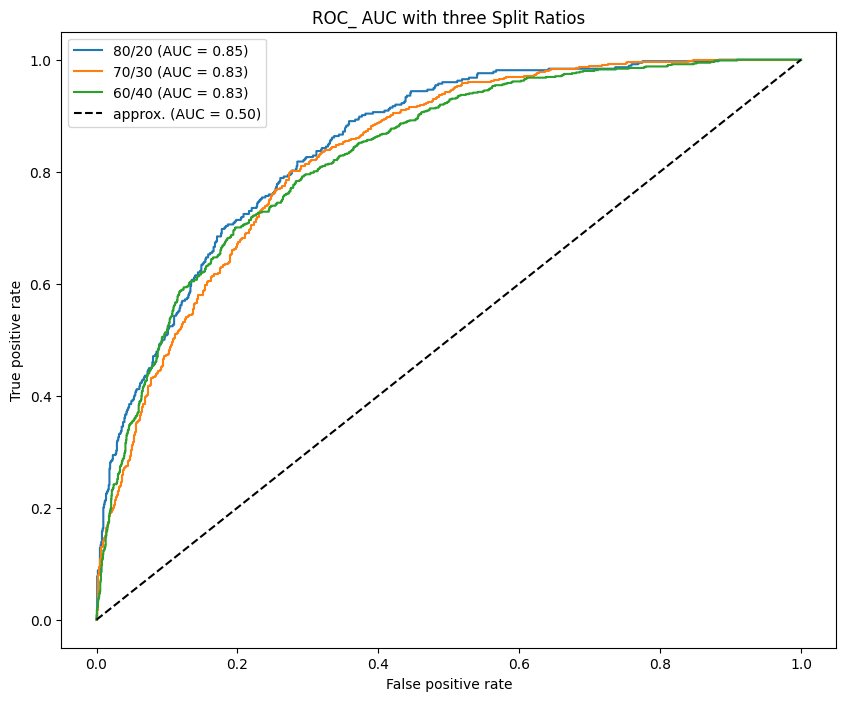

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

x = df.drop(columns=["Churn"]).copy()
y = df["Churn"].map({"Yes": 1, "No": 0})
splits = {
    "80/20": 0.20,
    "70/30": 0.30,
    "60/40": 0.40
}
plt.figure(figsize=(10, 8))
for label, ratio in splits.items():
  X_train, X_test, y_train, y_test = train_test_split(
      x, y, test_size=ratio, stratify=y
  )
  full_pipeline.fit(X_train, y_train)
  y_pred = full_pipeline.predict(X_test)
  y_prob = full_pipeline.predict_proba(X_test)[:, 1]
  print("\n Confusion matrix:")
  print(confusion_matrix(y_test, y_pred))
  print("\n Classification report:")
  print(classification_report(y_test, y_pred))
  auc_score = roc_auc_score(y_test, y_prob)
  print(f"ROC_AUC: {auc_score}")
  fpr, tpr, _ = roc_curve(y_test, y_prob)
  plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="approx. (AUC = 0.50)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC_ AUC with three Split Ratios")
plt.legend()
plt.show()

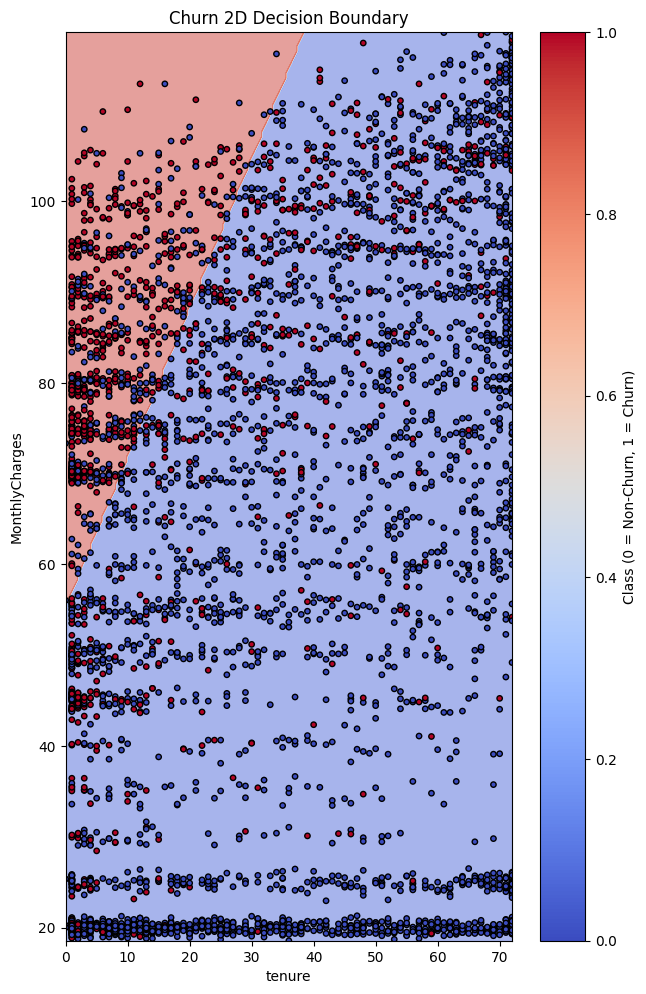

In [152]:
#Generate a 2D decision boundary visualization or inspect model feature coefficients to interpret how the model separates churning customers from retained customers.
# Select two prominent numerical features for 2D visualization
feat_1 = 'tenure'
feat_2 = 'MonthlyCharges'

X_2d = X_train[[feat_1, feat_2]].copy()

# Build a pipeline for these two features
clf_2d = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42))
])

# Train the 2D model
clf_2d.fit(X_2d, y_train)

# Create a mesh grid to plot the decision boundary
x_min, x_max = X_2d[feat_1].min() , X_2d[feat_1].max()
y_min, y_max = X_2d[feat_2].min() , X_2d[feat_2].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict over the mesh grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid_points, columns=[feat_1, feat_2])
Z = clf_2d.predict(grid_df)
Z = Z.reshape(xx.shape)

# Plotting the decision boundary and data points
plt.figure(figsize=(7.2, 11.8))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm)

# Scatter plot of training samples
scatter = plt.scatter(X_2d[feat_1], X_2d[feat_2], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', s=15, alpha=1)
plt.xlabel(feat_1)
plt.ylabel(feat_2)
plt.title('Churn 2D Decision Boundary')
plt.colorbar(scatter, label='Class (0 = Non-Churn, 1 = Churn)')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()